## 0. Carga del conjunto de datos

El archivo `datos_8414.npz` contiene las señales personalizadas para esta evaluación. A partir de este archivo se cargan tres arreglos principales:

- $X$: matriz de señales, donde cada fila corresponde a una señal temporal.
- $y$: etiquetas de régimen de dispersión.
- $t$: vector temporal común a todas las señales.

En particular,

$$
X \in \mathbb{R}^{24 \times 256},
$$

lo cual significa que el conjunto contiene $24$ señales, cada una muestreada en $256$ instantes de tiempo. Las etiquetas

$$
y \in \{0,1,2\}
$$

indican el régimen físico asociado a cada señal:

- $y=0$: régimen sin dispersión.
- $y=1$: régimen de dispersión intermedia.
- $y=2$: régimen de dispersión fuerte.

In [2]:
# ============================================================
# Imports
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

In [3]:
# ============================================================
# Carga del conjunto de datos
# ============================================================

datos = np.load("datos_8414.npz")

X = datos["X"]
y = datos["y"]
t = datos["t"]

## Configuración de estilo

In [4]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,

    "axes.labelsize": 16,
    "axes.titlesize": 18,

    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    "grid.color": "gray",
    "grid.linewidth": 0.3,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

##  Exploración inicial del conjunto de datos

Antes de construir el modelo de reconstrucción, es necesario inspeccionar la estructura del conjunto de datos. En esta sección se verifican las dimensiones de las variables principales y se visualiza una señal representativa de cada régimen de dispersión.

Esta exploración inicial permite confirmar que las señales están organizadas correctamente y ofrece una primera comparación cualitativa entre los tres regímenes físicos presentes en los datos:

$$
y \in \{0,1,2\}.
$$

En particular, se busca observar cómo cambia la estructura temporal de las señales $x(t)$ antes de introducir la capa Fourier y entrenar la red neuronal.

In [5]:
# ============================================================
# Exploración inicial
# ============================================================

print("X:", X.shape) # 24 señales , 8 por regimen r0 sin disp, r1 disp interm, r2 disp alta.
print("y:", y.shape)
print("t:", t.shape)

print("Regímenes:", np.unique(y, return_counts=True))

X: (24, 256)
y: (24,)
t: (256,)
Regímenes: (array([0, 1, 2]), array([8, 8, 8]))


La matriz $X$ tiene dimensión $24\times256$, por lo que cada fila representa una señal temporal $x(t)$ discretizada en $256$ puntos. La distribución de etiquetas confirma que hay $8$ señales por cada régimen de dispersión.

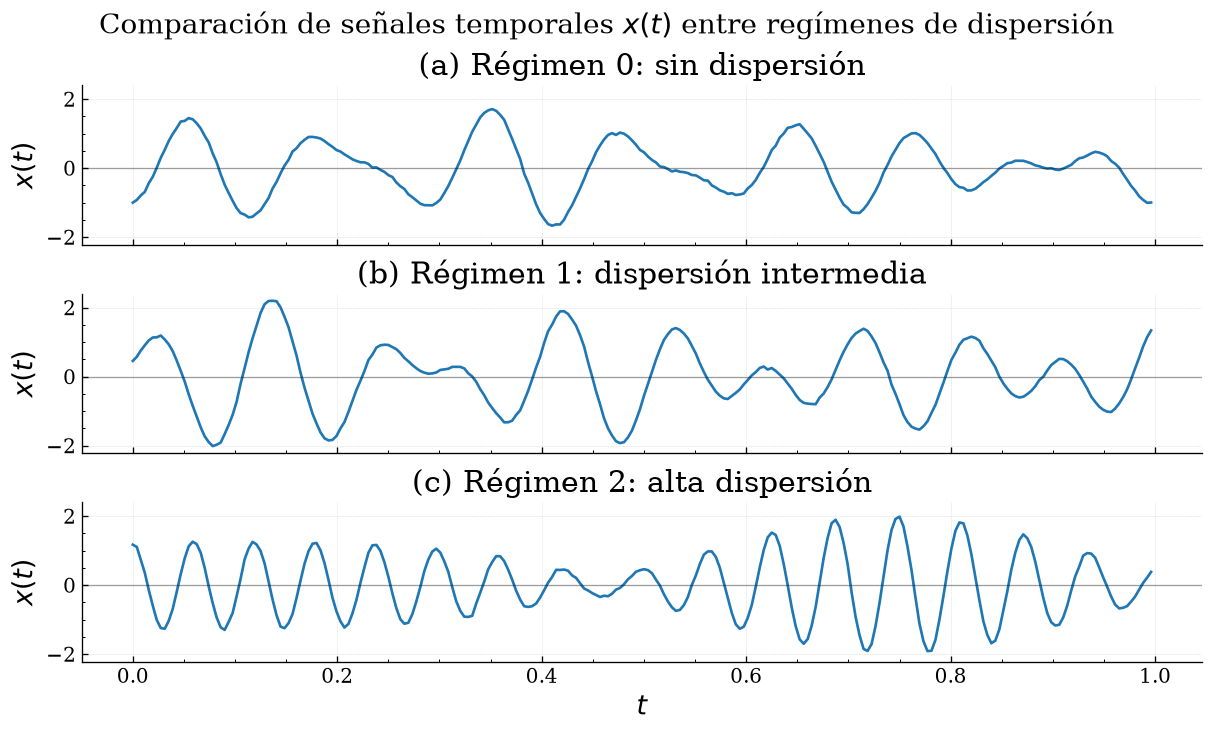

In [6]:
indices = [np.where(y == r)[0][0] for r in range(3)]#buscar la primera señal de cada regimen

titulos = [
    r"(a) Régimen 0: sin dispersión",
    r"(b) Régimen 1: dispersión intermedia",
    r"(c) Régimen 2: alta dispersión",
]

fig, axs = plt.subplots(
    3, 1,
    figsize=(10, 6),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for r, idx in enumerate(indices):
    axs[r].plot(t, X[idx], linewidth=1.6)
    axs[r].axhline(0, color="black", linewidth=0.8, alpha=0.35)
    axs[r].set_title(titulos[r])
    axs[r].set_ylabel(r"$x(t)$")
    axs[r].grid(True)

axs[-1].set_xlabel(r"$t$")

fig.suptitle(
    r"Comparación de señales temporales $x(t)$ entre regímenes de dispersión"
)

plt.show()

**Figura 1.** Señales temporales representativas $x(t)$ para los tres regímenes de dispersión. Se seleccionó una señal de cada etiqueta $y\in\{0,1,2\}$. La figura permite comparar cualitativamente la estructura temporal de las señales antes del entrenamiento de la red neuronal.

## 1. Capa Fourier

En esta sección se construye la capa Fourier que se utilizará para inicializar la primera capa de la red neuronal. Esta capa está formada por filas de senos y cosenos, tal como se pide en la rúbrica.

La matriz se denota por

$$
W_1 \in \mathbb{R}^{2K \times N},
$$

donde $N$ es el número de muestras temporales de cada señal. En este caso,

$$
N = 256.
$$

Se toma $K=20$, por lo que la capa Fourier tiene $2K=40$ filas.

Para cada frecuencia $k=1,\dots,K$, se incorporan las funciones

$$
\sin(2\pi k t)
$$

y

$$
\cos(2\pi k t).
$$

En la implementación, estas funciones se evalúan sobre los puntos temporales de cada señal para formar las filas de $W_1$.


### 1.1 Construcción de la capa Fourier

Como $K=20$ y $N=256$, la construcción de la capa Fourier produce una matriz

$$
W_1\in\mathbb{R}^{2K\times N}
=
\mathbb{R}^{40\times256}
$$

dada por

$$
W_1 =
\begin{bmatrix}
\sin(2\pi\cdot1\cdot \tau_0) & \cdots & \sin(2\pi\cdot1\cdot \tau_{255})\\
\vdots & \ddots & \vdots\\
\sin(2\pi\cdot20\cdot \tau_0) & \cdots & \sin(2\pi\cdot20\cdot \tau_{255})\\
\cos(2\pi\cdot1\cdot \tau_0) & \cdots & \cos(2\pi\cdot1\cdot \tau_{255})\\
\vdots & \ddots & \vdots\\
\cos(2\pi\cdot20\cdot \tau_0) & \cdots & \cos(2\pi\cdot20\cdot \tau_{255})
\end{bmatrix}.
$$

Aquí $\tau_j=j/N$ corresponde al tiempo normalizado en el que se evalúan las funciones seno y coseno para construir las filas de la capa Fourier.

In [7]:
K = 20
N = X.shape[1]

tau = jnp.arange(N) / N
k = jnp.arange(1, K + 1)

W1_sin = jnp.sin(2 * jnp.pi * k[:, None] * tau[None, :])
W1_cos = jnp.cos(2 * jnp.pi * k[:, None] * tau[None, :])

W1 = jnp.vstack([W1_sin, W1_cos])

print("W1.shape =", W1.shape)
print("N =", N)

W1.shape = (40, 256)
N = 256


### 1.2 Verificación frente a `np.fft` (Transformada Discreta de Fourier)

Inicialmente se selecciona una señal del conjunto de datos y se calcula la salida de la capa Fourier:

$$
z = W_1x.
$$

Este paso permite verificar las dimensiones de la operación. Como $x\in\mathbb{R}^{256}$ y $W_1\in\mathbb{R}^{40\times256}$, la salida debe cumplir

$$
z\in\mathbb{R}^{40}.
$$

In [13]:
# Seleccionar una señal del conjunto de datos
x = jnp.array(X[0])

# Aplicar la capa Fourier
z = W1 @ x

print("x.shape =", x.shape)
print("z.shape =", z.shape)

x.shape = (256,)
z.shape = (40,)


In [14]:
print("Coeficientes asociados a las funciones seno:")
print(z[:K])

print("\nCoeficientes asociados a las funciones coseno:")
print(z[K:])

Coeficientes asociados a las funciones seno:
[ 4.47720408e-01  3.34008038e-01  1.08840138e-01  8.68191719e-01
  8.13249588e-01 -5.50313830e-01 -4.36632614e+01  5.54417953e+01
  3.17084675e+01  1.12890526e+02 -4.41303711e+01 -1.75283127e+01
 -1.09743843e+01 -7.88773918e+00 -6.14795303e+00 -5.41703176e+00
 -4.60955524e+00 -3.61072922e+00 -2.62812662e+00 -3.18041635e+00]

Coeficientes asociados a las funciones coseno:
[ 7.8463984e-01  8.2724839e-01  1.0779440e+00  1.3935046e+00
  2.2512667e+00  4.7395577e+00  9.8476761e+01  1.3783740e+01
  3.9818048e-02  3.6207123e+00 -3.0463669e+00 -1.3111539e+00
 -1.2671571e+00 -1.2948383e+00 -3.1015587e-01 -6.5350223e-01
 -9.9100471e-01 -8.4934640e-01 -1.0859661e+00 -9.9274158e-02]


Los primeros K valores corresponden a las proyecciones sobre funciones seno, mientras que los últimos K corresponden a las proyecciones sobre funciones coseno. Para verificar que estos coeficientes coinciden con una representación de Fourier, se comparan a continuación con `np.fft.rfft`.




La Transformada Discreta de Fourier entrega coeficientes complejos. Su parte real está asociada a las funciones coseno, mientras que los coeficientes seno de la capa Fourier coinciden con el negativo de la parte imaginaria de `np.fft.rfft`, debido a la convención exponencial usada por NumPy.

In [15]:
# Transformada Discreta de Fourier de la señal seleccionada usando NumPy
X_fft = np.fft.rfft(np.array(x))

# Se toman las primeras K frecuencias no nulas: k = 1, ..., K
fft_k = X_fft[1:K + 1]

# Coeficientes obtenidos por la capa Fourier
# W1 está organizado como [senos, cosenos]
z = np.array(W1 @ x)
z_sin = z[:K]
z_cos = z[K:]

# Comparación con la FFT
print("Coeficientes coseno de W1x:")
print(np.round(z_cos, 3))

print("\nParte real de la FFT:")
print(np.round(np.real(fft_k), 3))

print("\nCoeficientes seno de W1x:")
print(np.round(z_sin, 3))

print("\nNegativo de la parte imaginaria de la FFT:")
print(np.round(-np.imag(fft_k), 3))

Coeficientes coseno de W1x:
[ 7.8500e-01  8.2700e-01  1.0780e+00  1.3940e+00  2.2510e+00  4.7400e+00
  9.8477e+01  1.3784e+01  4.0000e-02  3.6210e+00 -3.0460e+00 -1.3110e+00
 -1.2670e+00 -1.2950e+00 -3.1000e-01 -6.5400e-01 -9.9100e-01 -8.4900e-01
 -1.0860e+00 -9.9000e-02]

Parte real de la FFT:
[ 7.8500e-01  8.2700e-01  1.0780e+00  1.3940e+00  2.2510e+00  4.7400e+00
  9.8477e+01  1.3784e+01  4.0000e-02  3.6210e+00 -3.0470e+00 -1.3110e+00
 -1.2670e+00 -1.2950e+00 -3.1000e-01 -6.5400e-01 -9.9100e-01 -8.4900e-01
 -1.0860e+00 -9.9000e-02]

Coeficientes seno de W1x:
[ 4.48000e-01  3.34000e-01  1.09000e-01  8.68000e-01  8.13000e-01
 -5.50000e-01 -4.36630e+01  5.54420e+01  3.17080e+01  1.12891e+02
 -4.41300e+01 -1.75280e+01 -1.09740e+01 -7.88800e+00 -6.14800e+00
 -5.41700e+00 -4.61000e+00 -3.61100e+00 -2.62800e+00 -3.18000e+00]

Negativo de la parte imaginaria de la FFT:
[ 4.4800e-01  3.3400e-01  1.0900e-01  8.6800e-01  8.1300e-01 -5.5000e-01
 -4.3663e+01  5.5442e+01  3.1708e+01  1.1289e+02 -

Los resultados muestran que los coeficientes asociados a las funciones coseno coinciden con la parte real de la Transformada Discreta de Fourier. Por otro lado, los coeficientes asociados a las funciones seno coinciden con el negativo de la parte imaginaria.

Esta diferencia de signo se debe a la convención utilizada en la definición compleja de la transformada, donde aparece el término $e^{-2\pi i k\tau}$. En consecuencia, la comparación confirma que la salida de la capa Fourier reproduce correctamente los coeficientes trigonométricos asociados a las primeras $K$ frecuencias no nulas de la Transformada Discreta de Fourier.

### 1.3 Energía media del dataset

La energía media del conjunto de datos se calcula como

$$
\frac{1}{24\cdot256}\sum_{i=1}^{24}\sum_{j=1}^{256} X_{ij}^{2}.
$$

Este valor resume la magnitud cuadrática promedio de las señales y permite caracterizar globalmente la escala de amplitud del conjunto de datos.

In [16]:
energia_media = (X**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.696


## 2. Entrenamiento y reconstrucción

Una vez construida y verificada la capa Fourier, el siguiente paso consiste en implementar y entrenar la red neuronal encargada de reconstruir las señales temporales del conjunto de datos.

La red recibe una señal

$$
x\in\mathbb{R}^{256}
$$

y produce una reconstrucción

$$
\hat{x}\in\mathbb{R}^{256}.
$$

La arquitectura utilizada tiene dos capas lineales separadas por una función de activación hiperbólica $\tanh$:

$$
\hat{x}=W_2\,\tanh(W_1x).
$$

La primera capa transforma la señal de entrada en una representación de dimensión $2K=40$, mientras que la segunda capa utiliza dicha representación para reconstruir la señal original.

Se comparan dos formas de inicializar la primera capa $W_1$:

- inicialización mediante la capa Fourier construida previamente;
- inicialización aleatoria.

En ambos casos, los parámetros se entrenan mediante descenso por gradiente.

### 2.1 Implementación de la red neuronal en JAX

In [17]:
# ============================
# Inicialización de parámetros
# ============================

def init_params(key, W1_init):
    key1, key2 = jax.random.split(key)

    params = {
        "W1": W1_init,
        "W2": 0.01 * jax.random.normal(key1, (N, 2 * K))
    }

    return params

In [18]:
def forward(params, x):
    """
    Propagación hacia adelante de la red neuronal.
    """

    W1 = params["W1"]
    W2 = params["W2"]

    h = jnp.tanh(W1 @ x)
    x_hat = W2 @ h

    return x_hat

La función de pérdida se define como el error cuadrático medio entre la señal original y la reconstrucción:

$$
\mathcal{L}(x,\hat{x})=\frac{1}{N}\|\hat{x}-x\|^2.
$$

In [19]:
def loss(params, x):
    x_hat = forward(params, x)
    return jnp.mean((x_hat - x) ** 2)

Para actualizar los parámetros se utiliza descenso por gradiente. En cada paso se calculan los gradientes de la pérdida con respecto a los parámetros de la red y se actualizan usando una tasa de aprendizaje $\eta=0.1$.

In [20]:
@jax.jit
def update(params, x, lr):
    grads = jax.grad(loss)(params, x)

    params = jax.tree_util.tree_map(
        lambda p, g: p - lr * g,
        params,
        grads
    )

    return params


def train(params, X_train, num_iters=4000, lr=0.1):
    losses = []

    X_train = jnp.array(X_train)

    for i in range(num_iters):
        total_loss = 0.0

        for x in X_train:
            params = update(params, x, lr)
            total_loss += loss(params, x)

        mean_loss = total_loss / X_train.shape[0]
        losses.append(mean_loss)

    return params, jnp.array(losses)

### 2.2 Entrenamiento con inicialización Fourier y aleatoria

Se entrenan dos redes con la misma arquitectura y los mismos hiperparámetros. La única diferencia entre ellas es la inicialización de la primera capa $W_1$.

En el primer caso, $W_1$ se inicializa con la matriz Fourier construida en la sección anterior. En el segundo caso, $W_1$ se inicializa de forma aleatoria.

El entrenamiento se realiza sobre todo el conjunto de datos, es decir, sobre señales de los tres regímenes de dispersión.

In [21]:
# Inicialización Fourier
key = jax.random.PRNGKey(42)
params_fourier = init_params(key, W1)

# Inicialización aleatoria
key, subkey = jax.random.split(key)

W1_random = 0.01 * jax.random.normal(subkey, (2 * K, N))
params_random = init_params(key, W1_random)

# Entrenamiento
num_iters = 4000
lr = 0.1

params_fourier_trained, losses_fourier = train(params_fourier, X, num_iters, lr)
params_random_trained, losses_random = train(params_random, X, num_iters, lr)

print("Loss final Fourier:", losses_fourier[-1])
print("Loss final aleatoria:", losses_random[-1])

Loss final Fourier: 9.259445e-12
Loss final aleatoria: 1.4766938e-11


### 2.3 Reconstrucción final por régimen

Una vez entrenadas ambas redes, se comparan las señales reconstruidas con las señales originales. Para visualizar el resultado, se selecciona una señal representativa de cada uno de los tres regímenes.

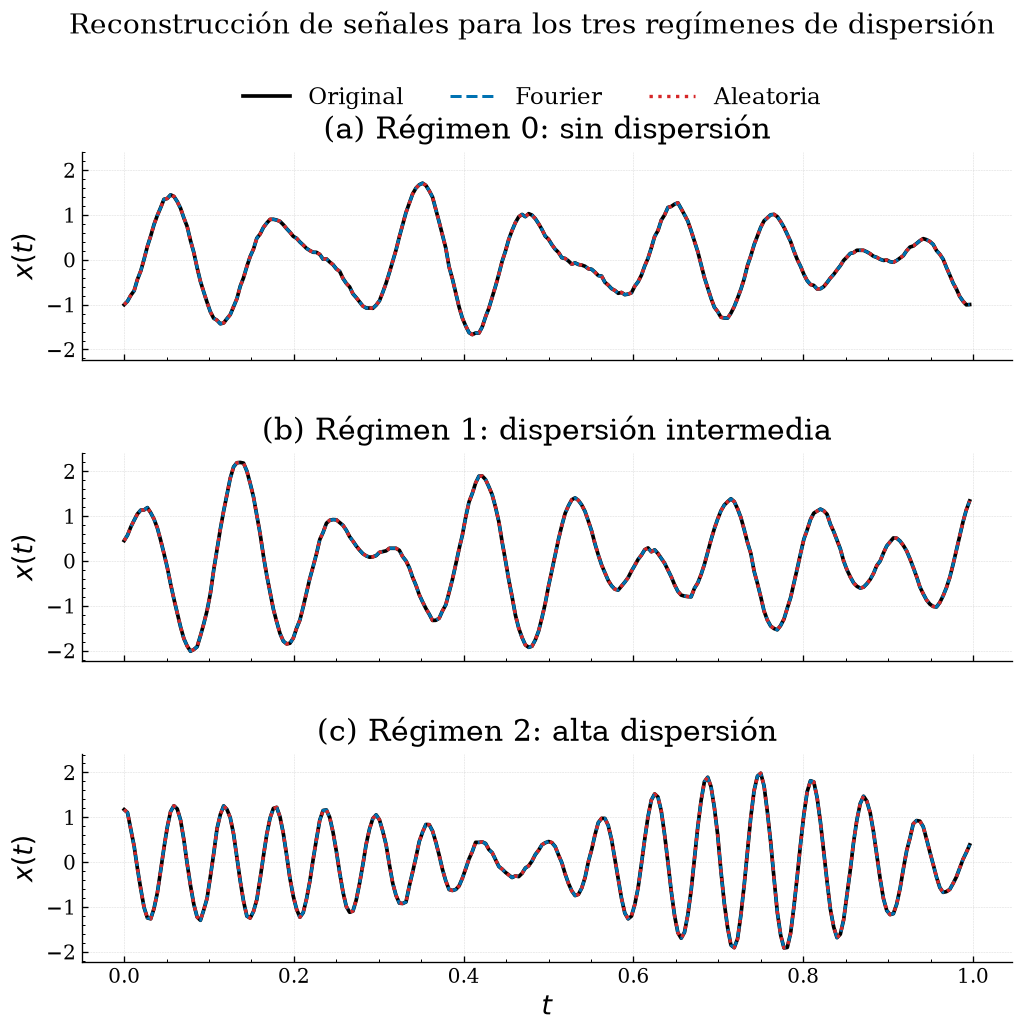

In [38]:
# Señales reconstruidas
X_fourier = jnp.array([forward(params_fourier_trained, x) for x in X])
X_random = jnp.array([forward(params_random_trained, x) for x in X])

indices = [np.where(y == r)[0][0] for r in range(3)]

titulos = [
    r"(a) Régimen 0: sin dispersión",
    r"(b) Régimen 1: dispersión intermedia",
    r"(c) Régimen 2: alta dispersión",
]

color_original = "black"
color_fourier = "#0072B2"
color_random = "#D62728"

fig, axs = plt.subplots(
    3, 1,
    figsize=(10, 9),
    sharex=True,
    sharey=True,
)

for ax, idx, titulo in zip(axs, indices, titulos):
    ax.plot(t, X[idx], color=color_original, linewidth=2.2, label="Original")
    ax.plot(t, X_fourier[idx], "--", color=color_fourier, linewidth=1.8, label="Fourier")
    ax.plot(t, X_random[idx], ":", color=color_random, linewidth=2.0, label="Aleatoria")

    ax.set_title(titulo, pad=8)
    ax.set_ylabel(r"$x(t)$")
    ax.grid(True)

axs[-1].set_xlabel(r"$t$")

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.94)
)


fig.suptitle(
    r"Reconstrucción de señales para los tres regímenes de dispersión",
    y=0.99
)

fig.subplots_adjust(
    top=0.86,
    hspace=0.45
)


plt.show()

**Figura 2.** Comparación entre las señales originales y las reconstrucciones finales obtenidas con inicialización Fourier y con inicialización aleatoria. Se muestra una señal representativa de cada régimen de dispersión. La superposición de las curvas indica que ambas redes logran reconstruir adecuadamente las señales después del entrenamiento.

### 2.4 Error relativo de reconstrucción

Como medida cuantitativa del desempeño de la red, se calcula el error relativo de reconstrucción definido por

$$
\varepsilon=
\frac{\|\hat{x}-x\|}{\|x\|},
$$

donde $x$ corresponde a la señal original y $\hat{x}$ a la reconstrucción obtenida por la red.

Este indicador permite comparar objetivamente la calidad de la reconstrucción para ambas estrategias de inicialización en cada régimen de dispersión.

In [23]:
def relative_error(x, x_hat):
    return jnp.linalg.norm(x_hat - x) / jnp.linalg.norm(x)

errors_fourier = []
errors_random = []

for x in X:
    x = jnp.array(x)

    x_fourier = forward(params_fourier_trained, x)
    x_random = forward(params_random_trained, x)

    errors_fourier.append(float(relative_error(x, x_fourier)))
    errors_random.append(float(relative_error(x, x_random)))

for r in range(3):

    idx = (y == r)

    ef = np.mean(np.array(errors_fourier)[idx])
    er = np.mean(np.array(errors_random)[idx])

    print(f"Régimen {r}")
    print(f"  Fourier   : {ef:.3e}")
    print(f"  Aleatoria : {er:.3e}")
    print()

Régimen 0
  Fourier   : 3.523e-06
  Aleatoria : 4.076e-06

Régimen 1
  Fourier   : 3.749e-06
  Aleatoria : 4.644e-06

Régimen 2
  Fourier   : 4.520e-06
  Aleatoria : 6.453e-06



Los errores relativos obtenidos son del orden de $10^{-6}$ para ambas estrategias de inicialización, lo que confirma la alta precisión de las reconstrucciones alcanzadas por la red. En los tres regímenes de dispersión, la inicialización basada en Fourier presenta errores relativos ligeramente menores que la inicialización aleatoria.

## 3. Comparación de inicializaciones

En esta sección se compara el efecto de inicializar la primera capa de la red neuronal con la base de Fourier frente a una inicialización aleatoria.

Aunque ambas redes tienen la misma arquitectura y se entrenan con los mismos hiperparámetros, el punto de partida de la primera capa $W_1$ es diferente. Por esta razón, se analiza la evolución de la pérdida durante el entrenamiento y la velocidad con la que cada inicialización reduce el error.

### 3.1 Evolución de la pérdida durante 4000 iteraciones

Para estudiar el comportamiento de ambas inicializaciones, se registra el valor de la función de pérdida en cada iteración del entrenamiento. El entrenamiento se realiza durante 4000 iteraciones con tasa de aprendizaje $\eta=0.1$, usando las señales de los tres regímenes.

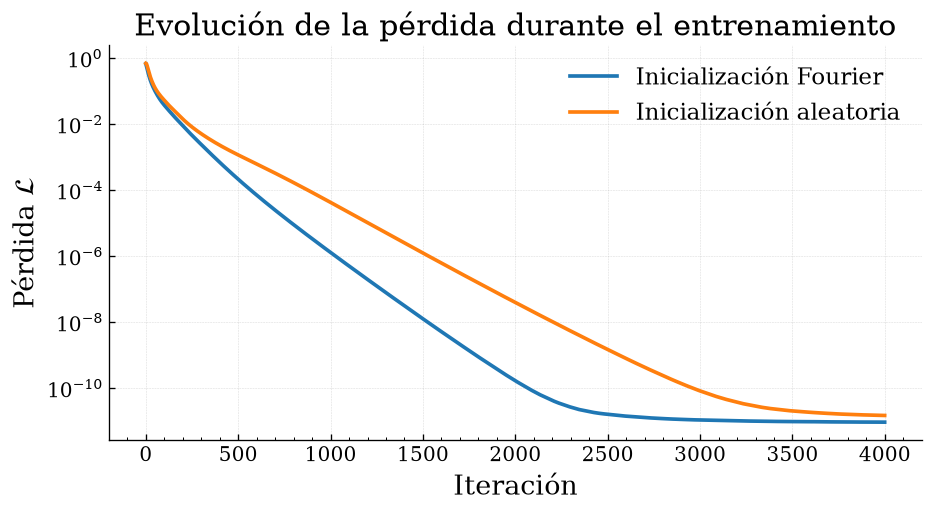

In [27]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(losses_fourier, linewidth=2.2, label="Inicialización Fourier")
ax.plot(losses_random, linewidth=2.2, label="Inicialización aleatoria")

ax.set_title(r"Evolución de la pérdida durante el entrenamiento")
ax.set_xlabel(r"Iteración")
ax.set_ylabel(r"Pérdida $\mathcal{L}$")
ax.set_yscale("log")

ax.grid(True)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

**Figura 3.** Evolución de la pérdida $\mathcal{L}$ en escala logarítmica durante las 4000 iteraciones de entrenamiento. Se comparan las redes inicializadas con la capa Fourier y con una matriz aleatoria.

In [28]:
print("Loss final Fourier:", losses_fourier[-1])
print("Loss final aleatoria:", losses_random[-1])

Loss final Fourier: 9.259445e-12
Loss final aleatoria: 1.4766938e-11


La figura muestra que ambas inicializaciones logran reducir la pérdida de reconstrucción hasta valores muy pequeños. La escala logarítmica permite observar con mayor claridad la disminución del error durante el entrenamiento.

El valor final de la pérdida fue

$$
\mathcal{L}_{\mathrm{Fourier}} = 9.26\times10^{-12},
$$

mientras que para la inicialización aleatoria fue

$$
\mathcal{L}_{\mathrm{aleatoria}} = 1.48\times10^{-11}.
$$

Aunque ambos errores finales son extremadamente pequeños, la inicialización Fourier alcanza una pérdida final ligeramente menor y, además, converge más rápido durante las primeras iteraciones.

### 3.2 Iteraciones necesarias para alcanzar error relativo menor que 0.1

Además de comparar la pérdida final, se mide cuántas iteraciones necesita cada inicialización para alcanzar un error relativo menor que $0.1$. Esta medida permite comparar la velocidad de convergencia de ambas estrategias.

In [29]:
threshold = 0.1

rel_errors_fourier = np.sqrt(np.array(losses_fourier) / energia_media)
rel_errors_random = np.sqrt(np.array(losses_random) / energia_media)

def first_below_threshold(errors, threshold=0.1):
    errors = np.array(errors)
    idx = np.where(errors < threshold)[0]
    return int(idx[0]) if len(idx) > 0 else None

iter_fourier = first_below_threshold(rel_errors_fourier, threshold)
iter_random = first_below_threshold(rel_errors_random, threshold)

print(
    "Inicialización Fourier  :",
    f"{iter_fourier} iteraciones" if iter_fourier is not None else "no alcanzó el umbral"
)

print(
    "Inicialización aleatoria:",
    f"{iter_random} iteraciones" if iter_random is not None else "no alcanzó el umbral"
)

Inicialización Fourier  : 219 iteraciones
Inicialización aleatoria: 266 iteraciones


La comparación del número de iteraciones necesarias para alcanzar el umbral $\varepsilon < 0.1$ permite evaluar no solo la precisión final, sino también la rapidez del aprendizaje. Si una inicialización alcanza este umbral en menos iteraciones, entonces mejora más rápido durante las etapas iniciales del entrenamiento.

### 3.3 Análisis del régimen 0: sin dispersión

El enunciado solicita prestar especial atención al régimen 0, correspondiente al caso sin dispersión. Para ello, la red se entrena nuevamente utilizando únicamente las señales con etiqueta $y=0$.

En este régimen, las señales presentan una estructura espectral dominada por frecuencias más bajas, por lo que resulta natural analizar si una inicialización basada en funciones de Fourier proporciona una convergencia más rápida que una inicialización aleatoria.

In [30]:
X_reg0 = X[y == 0]

key = jax.random.PRNGKey(123)

params_fourier_reg0 = init_params(key, W1)

key, subkey = jax.random.split(key)
W1_random_reg0 = 0.01 * jax.random.normal(subkey, (2 * K, N))
params_random_reg0 = init_params(key, W1_random_reg0)

params_fourier_reg0_trained, losses_fourier_reg0 = train(
    params_fourier_reg0,
    X_reg0,
    num_iters,
    lr
)

params_random_reg0_trained, losses_random_reg0 = train(
    params_random_reg0,
    X_reg0,
    num_iters,
    lr
)

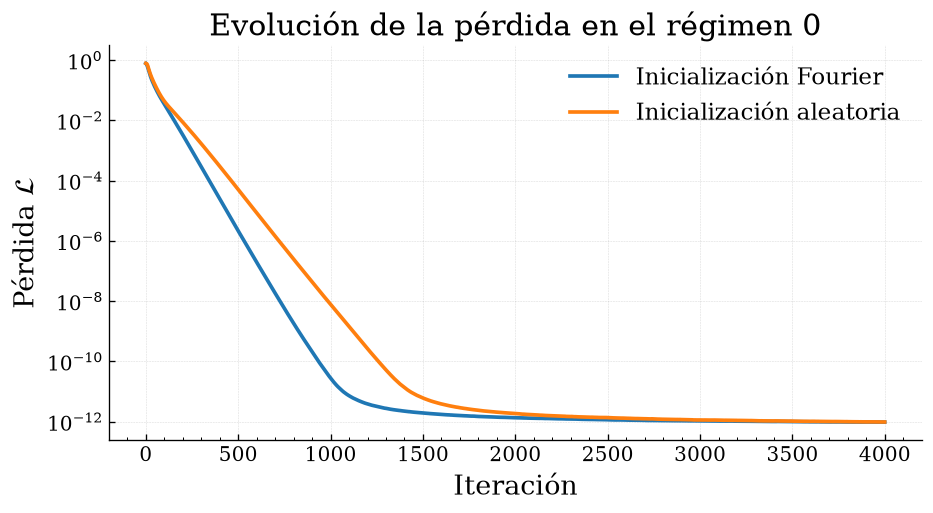

In [31]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(losses_fourier_reg0, linewidth=2.2, label="Inicialización Fourier")
ax.plot(losses_random_reg0, linewidth=2.2, label="Inicialización aleatoria")

ax.set_title(r"Evolución de la pérdida en el régimen 0")
ax.set_xlabel(r"Iteración")
ax.set_ylabel(r"Pérdida $\mathcal{L}$")
ax.set_yscale("log")

ax.grid(True)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

**Figura 4.** Evolución de la pérdida para las señales del régimen 0, correspondiente al caso sin dispersión. Se comparan las inicializaciones Fourier y aleatoria bajo las mismas condiciones de entrenamiento.

En el régimen 0, la inicialización Fourier resulta especialmente natural porque las señales se componen de frecuencias bien definidas. Por ello, iniciar la primera capa con funciones seno y coseno puede facilitar que la red encuentre una representación adecuada desde las primeras iteraciones.

In [32]:
print("Loss final Fourier régimen 0:", losses_fourier_reg0[-1])
print("Loss final aleatoria régimen 0:", losses_random_reg0[-1])

Loss final Fourier régimen 0: 9.569633e-13
Loss final aleatoria régimen 0: 9.674276e-13


In [33]:
energia_reg0 = (X_reg0**2).mean()

rel_errors_fourier_reg0 = np.sqrt(np.array(losses_fourier_reg0) / energia_reg0)
rel_errors_random_reg0 = np.sqrt(np.array(losses_random_reg0) / energia_reg0)

iter_fourier_reg0 = first_below_threshold(rel_errors_fourier_reg0, threshold)
iter_random_reg0 = first_below_threshold(rel_errors_random_reg0, threshold)

print("Iteraciones Fourier régimen 0:", iter_fourier_reg0)
print("Iteraciones aleatoria régimen 0:", iter_random_reg0)

Iteraciones Fourier régimen 0: 164
Iteraciones aleatoria régimen 0: 207


Los resultados del régimen 0 permiten observar con mayor detalle la diferencia de velocidad entre ambas inicializaciones. En particular, la inicialización Fourier alcanza $\varepsilon < 0.1$ en **164 iteraciones**, mientras que la inicialización aleatoria lo hace en **207 iteraciones**.


